# 🚀 Project: Demand Forecasting System

---

## 📌 1. Project Overview

### 🧠 What is this project?
A **Machine Learning–based Demand Forecasting System** that predicts product demand using historical retail data such as:
- Price  
- Discount  
- Inventory Levels  
- Promotions  
- Competitor Pricing  
- Seasonality  

---

### 🎯 Business Goal
This project helps businesses answer key questions:

- 📈 How much demand will occur?  
- 📦 How much stock should we maintain?  
- 🎯 When should we run promotions?  
- 💰 How should we price products vs competitors?  

---

### 💼 Business Impact
- ✅ Reduce stockouts & overstock  
- 📊 Improve inventory planning  
- 💸 Increase revenue via smart pricing  
- 🎯 Better promotion strategy  

---

### 🔍 Problem Type
- **Type:** Regression Problem  
- **Target Variable:** `Demand`

## 📂 Project Structure

Demand-Forecasting-System/
│
├── data/
│   └── demand_forecasting.csv
│
├── notebooks/
│   └── EDA_Model.ipynb
│
├── src/
│   ├── preprocessing.py
│   ├── train.py
│   ├── predict.py
│
├── models/
│   └── model_pipeline.pkl
│
├── app.py
├── requirements.txt
└── README.md

📊  Data Loading

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("demand_forecasting.csv")

In [3]:
print(df.shape)
df.head()

(76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


## Data Cleaning

In [4]:
# Check missing values
df.isnull().sum()



Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [6]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
# Drop ID columns (not useful for prediction)
df.drop(['Store ID', 'Product ID'], axis=1, inplace=True)

In [8]:
# Check duplicates
df.drop_duplicates(inplace=True)

In [9]:
# Final check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Category            76000 non-null  object        
 2   Region              76000 non-null  object        
 3   Inventory Level     76000 non-null  int64         
 4   Units Sold          76000 non-null  int64         
 5   Units Ordered       76000 non-null  int64         
 6   Price               76000 non-null  float64       
 7   Discount            76000 non-null  int64         
 8   Weather Condition   76000 non-null  object        
 9   Promotion           76000 non-null  int64         
 10  Competitor Pricing  76000 non-null  float64       
 11  Seasonality         76000 non-null  object        
 12  Epidemic            76000 non-null  int64         
 13  Demand              76000 non-null  int64     

## 📊 Exploratory Data Analysis

## Target Analysis

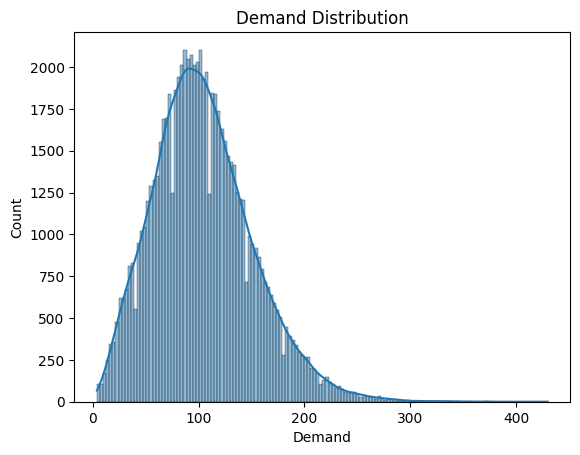

In [10]:
sns.histplot(df['Demand'], kde=True)
plt.title("Demand Distribution")
plt.show()

- Demand is **right-skewed**, with most values in the mid-range  
- A few **high-demand outliers** are present  
- Model should handle **variance and skewness** effectively  


## Category vs Demand

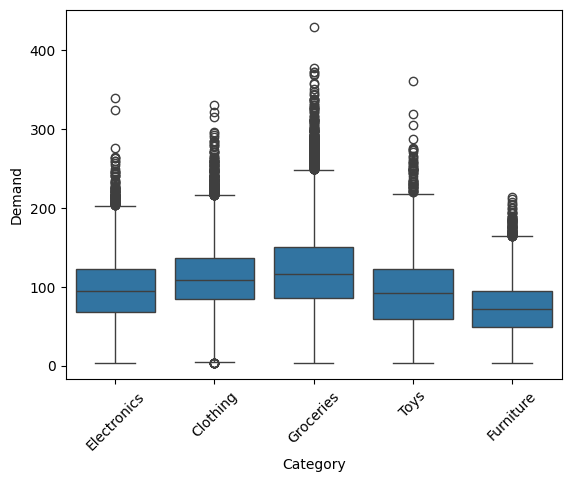

In [11]:
sns.boxplot(x='Category', y='Demand', data=df)
plt.xticks(rotation=45)
plt.show()

- **Groceries & Clothing** → Higher demand  
- **Furniture** → Lower demand  
- Category plays a **significant role in demand variation** 

## Promotion Impact

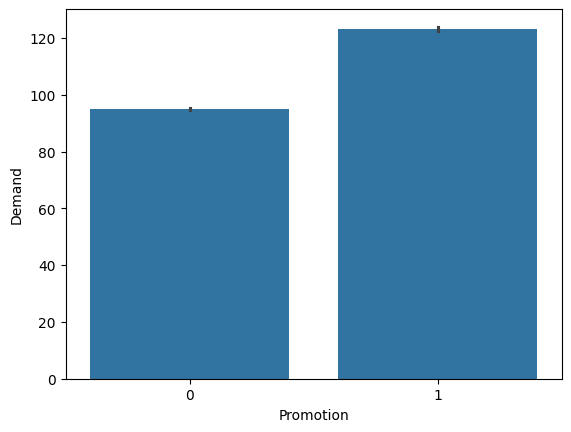

In [12]:
sns.barplot(x='Promotion', y='Demand', data=df)
plt.show()

- Products with **promotions have higher average demand**  
- Promotions are effective in **boosting sales**  
- Strong and important **feature for modeling**  

## Price vs Demand

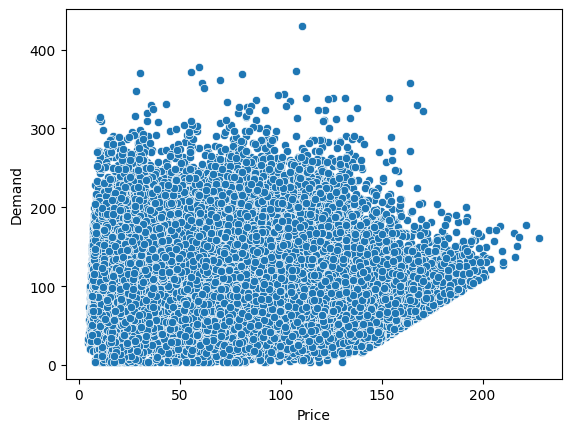

In [13]:
sns.scatterplot(x='Price', y='Demand', data=df)
plt.show()

- Demand **decreases as price increases**  
- Clear **inverse relationship** observed  
- Pricing is a **key driver of demand**  

## Region Analysis

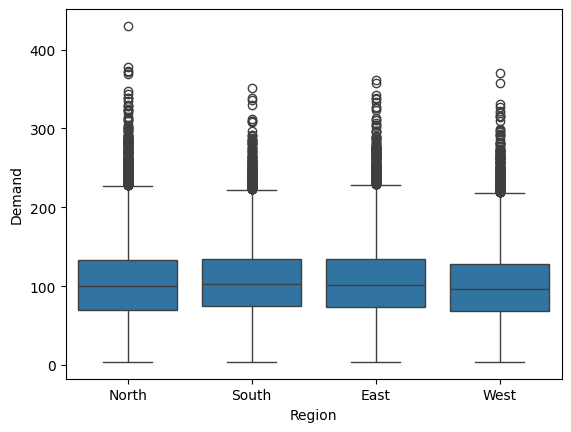

In [14]:
sns.boxplot(x='Region', y='Demand', data=df)
plt.show()

- Demand is **fairly consistent across regions**  
- No major regional imbalance detected  
- Region has a **moderate impact**

## 🧠 Overall EDA Summary

> Demand is influenced by **pricing, promotions, and product category**.  
> Price shows a **negative correlation** with demand, while promotions significantly **increase sales**.  
> Category-level differences are strong, whereas **regional variation is relatively stable**.

## ⚙️ Feature Engineering

In [15]:
# Work on a copy
df_fe = df.copy()

In [16]:
# 1. Date Features
# -----------------------------
df_fe['Year'] = df_fe['Date'].dt.year
df_fe['Month'] = df_fe['Date'].dt.month
df_fe['Day'] = df_fe['Date'].dt.day
df_fe['DayOfWeek'] = df_fe['Date'].dt.dayofweek
df_fe['IsWeekend'] = df_fe['DayOfWeek'].isin([5, 6]).astype(int)


In [17]:
# 2. Pricing Intelligence
# -----------------------------
df_fe['Price_Diff'] = df_fe['Price'] - df_fe['Competitor Pricing']
df_fe['Price_Ratio'] = df_fe['Price'] / (df_fe['Competitor Pricing'] + 1)

In [18]:
# 3. Inventory Features
# -----------------------------
df_fe['Stock_Coverage'] = df_fe['Inventory Level'] / (df_fe['Inventory Level'].mean())

In [19]:
# 4. Interaction Features
# -----------------------------
df_fe['Promo_Discount'] = df_fe['Promotion'] * df_fe['Discount']
df_fe['Promo_Season'] = df_fe['Promotion'] * (df_fe['Seasonality'] == 'Winter').astype(int)

In [20]:
# 5. External Impact
# -----------------------------
df_fe['Bad_Weather'] = (df_fe['Weather Condition'] == 'Snowy').astype(int)
df_fe['Epidemic_Impact'] = df_fe['Epidemic'] * df_fe['Promotion']

In [21]:
# 6. Drop Leakage / Unnecessary Columns
# -----------------------------
df_fe.drop(['Date', 'Units Sold', 'Units Ordered'], axis=1, inplace=True)

In [22]:
df_fe.head()

,Category,Region,Inventory Level,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,...,Day,DayOfWeek,IsWeekend,Price_Diff,Price_Ratio,Stock_Coverage,Promo_Discount,Promo_Season,Bad_Weather,Epidemic_Impact
0,Electronics,North,195,72.72,5,Snowy,0,85.73,Winter,0,...,1,5,1,-13.01,0.838464,0.647705,0,0,1,0
1,Clothing,North,117,80.16,15,Snowy,1,92.02,Winter,0,...,1,5,1,-11.86,0.861750,0.388623,15,1,1,0
2,Clothing,North,247,62.94,10,Snowy,1,60.08,Winter,0,...,1,5,1,2.86,1.030452,0.820427,10,1,1,0
3,Electronics,North,139,87.63,10,Snowy,0,85.19,Winter,0,...,1,5,1,2.44,1.016707,0.461698,0,0,1,0
4,Groceries,North,152,54.41,0,Snowy,0,51.63,Winter,0,...,1,5,1,2.78,1.033821,0.504878,0,0,1,0


In [23]:
df_fe['Log_Inventory'] = np.log1p(df_fe['Inventory Level'])

## Train-Test Split

In [24]:
# Target & Features
X = df_fe.drop('Demand', axis=1)
y = df_fe['Demand']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

cat_cols, num_cols[:5]

(['Category', 'Region', 'Weather Condition', 'Seasonality'],
 ['Inventory Level', 'Price', 'Discount', 'Promotion', 'Competitor Pricing'])

In [25]:
print("Categorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

Categorical Columns:
['Category', 'Region', 'Weather Condition', 'Seasonality']

Numerical Columns:
['Inventory Level', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic', 'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Price_Diff', 'Price_Ratio', 'Stock_Coverage', 'Promo_Discount', 'Promo_Season', 'Bad_Weather', 'Epidemic_Impact', 'Log_Inventory']


### Preprocessing (Pipeline-Safe)

In [26]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

## Train Multiple Models

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42)
}

## Model Evaluation

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []
fitted_pipes = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(results).sort_values(by="MAE")
results_df

,Model,MAE,RMSE,R2
1,RandomForest,21.273241,29.481405,0.606454
2,XGBoost,21.977812,29.312745,0.610944
0,Linear,26.870435,34.830762,0.450680


In [29]:
best_model_name = results_df.iloc[0]['Model']
print("Best Model:", best_model_name)

Best Model: RandomForest


In [30]:
print(results_df)

          Model        MAE       RMSE        R2
1  RandomForest  21.273241  29.481405  0.606454
2       XGBoost  21.977812  29.312745  0.610944
0        Linear  26.870435  34.830762  0.450680


## Hyperparameter Tuning

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

param_dist = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',  # IMPORTANT
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

## Evaluate Tuned Model

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

preds = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2:", r2_score(y_test, preds))

MAE: 21.36919977339183
RMSE: 29.456673960038184
R2: 0.6071136740213793


In [33]:
best_model = fitted_pipes["RandomForest"]

## Final Evaluation

In [34]:
preds = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2:", r2_score(y_test, preds))

MAE: 21.273241447368424
RMSE: 29.481405499461594
R2: 0.6064536699292675


## Feature Importance

In [35]:
# Extract feature names
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_cols = ohe.get_feature_names_out(cat_cols)

all_features = list(encoded_cat_cols) + num_cols

# Importance
import pandas as pd

importances = best_model.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp.head(15)

,Feature,Importance
18,Price,0.165738
22,Epidemic,0.132431
3,Category_Groceries,0.090662
21,Competitor Pricing,0.065522
2,Category_Furniture,0.050388
31,Promo_Discount,0.043135
20,Promotion,0.042985
25,Day,0.038595
29,Price_Ratio,0.037393
0,Category_Clothing,0.036240


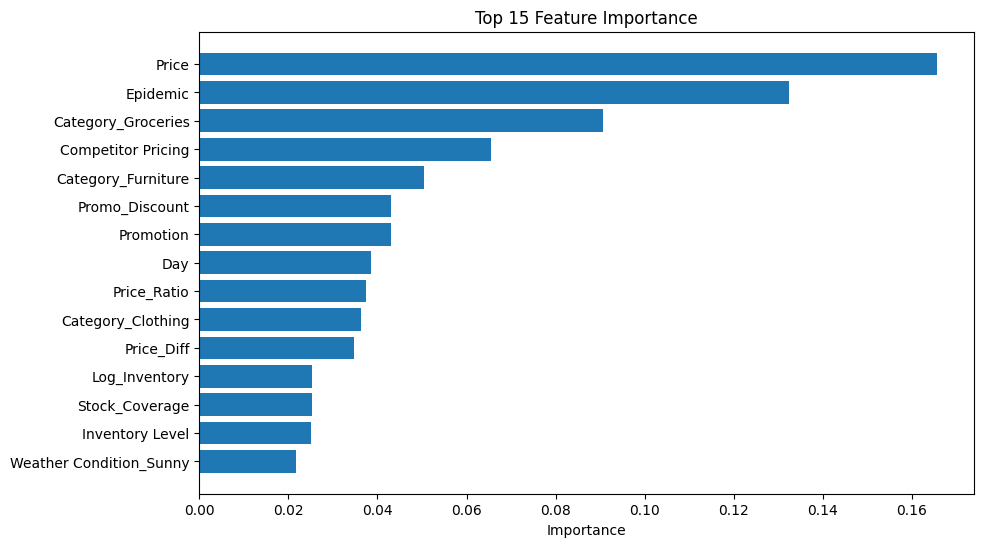

In [36]:
import matplotlib.pyplot as plt

# Top 15 features
top_n = 15
feat_imp_top = feat_imp.head(top_n)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp_top['Feature'], feat_imp_top['Importance'])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importance")
plt.gca().invert_yaxis()  # Highest on top
plt.show()

In [37]:
import os
import joblib

# Create folder if not exists
os.makedirs("models", exist_ok=True)

# Save model
joblib.dump(best_model, "models/demand_model.pkl")

['models/demand_model.pkl']

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Use your existing preprocessor
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),   # your ColumnTransformer
    ('model', model)
])

# Train
final_pipeline.fit(X_train, y_train)

# Save FULL pipeline
import joblib
joblib.dump(final_pipeline, "models/demand_model.pkl")

['models/demand_model.pkl']